<a href="https://colab.research.google.com/github/Floriannee/Projet_DL_ExpressionFaciale/blob/main/Projet_Deep_Learning_%E2%80%94_Expressions_faciales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lien slide : https://docs.google.com/presentation/d/1KQ7g3Xd5BOueTLmQuZdsx3iqJ7iMBVM0Y4K8rr1V4bM/edit?usp=sharing




# Partie 1: Recherche, compréhension et préparation des données

## Description du dataset

Source du dataset FER-2013 (Facial Expression Recognition 2013)

*   Lien: https://www.kaggle.com/datasets/msambare/fer2013
*   Auteurs: Pierre-Luc Carrier et Aaron Courville (Challenge ICML 2013)
*   Licence d'utilisation: Open Database, subject to competition rules.


Nombre total d'images : Le dataset contient un total de 35 887 images réparties entre les ensembles d'entraînement et de test.

Les différentes classes : Le problème est une classification multiclasse à 7 catégories d'expressions faciales fondamentales : Colère (Angry), Dégoût (Disgust), Peur (Fear), Joie (Happy), Tristesse (Sad), Surprise (Surprise), Neutre (Neutral).

| Classes | Nombres d'images (train) | Nombres d'images (test) | Total |
|---|---|---|---|
| Angry | 3 995 | 958 | 4 953 |
| Disgust | 436 | 111 | 547 |
| Fear | 4 097 | 1 024 | 5 121 |
| Happy | 7 215 | 1 774 | 8 989 |
| Neutral | 4 965 | 1 233 | 6 198 |
| Sad | 4 830 | 1 247 | 6 077 |
| Surprise | 3 171 | 831 | 4 002 |
| Total | 28 709 | 7 178 | 35 887 |

Dimension des images: 48 pixels * 48 pixels <br>
Format des images: fichiers .jpg avec des niveaux de gris <br>
La classe Disgust est nettement sous-représentée par rapport aux autres classes.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)

100%|██████████| 60.3M/60.3M [00:00<00:00, 135MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/msambare/fer2013/versions/1


In [ ]:
import tensorflow as tf

train_dir = path + "/train"
test_dir = path + "/test"

# Chargement du jeu d'entraînement

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(48, 48),
    color_mode='grayscale',  # Important car FER-2013 est en noir et blanc
    batch_size=64,
    label_mode='categorical',   # Pour du One-Hot Encoding (nécessaire avec Softmax / categorical_crossentropy)
    shuffle=True
)

# Chargement du jeu de test

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(48, 48),
    color_mode='grayscale',
    batch_size=64,
    label_mode='categorical',
    shuffle=False
)


# Récupération des noms des classes
class_names = train_dataset.class_names
print("Classes détectées :", class_names)

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.
Classes détectées : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


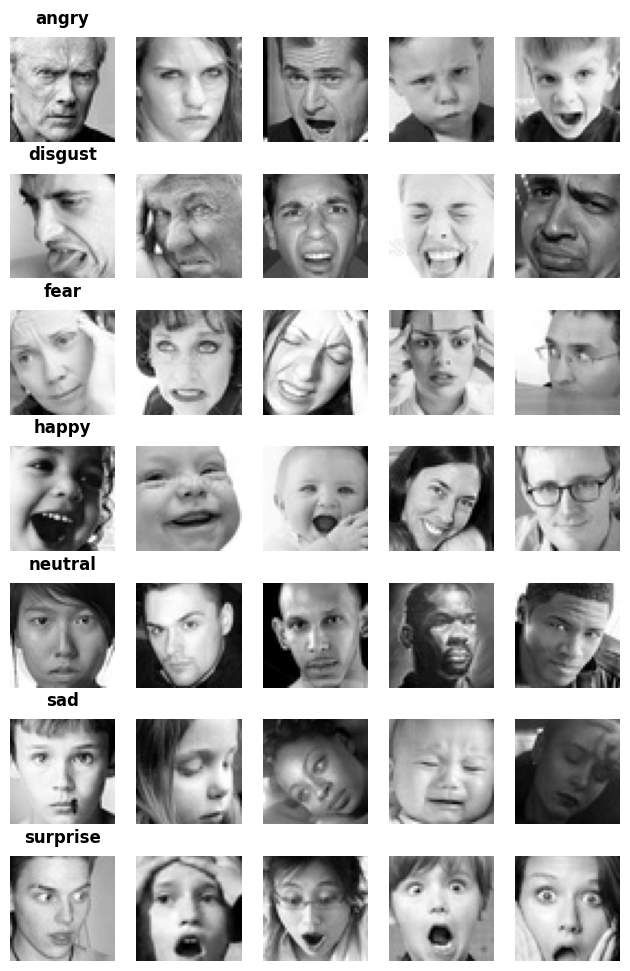

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(7, 5, figsize=(8, 12))
plt.subplots_adjust(wspace=0.1, hspace=0.3)
counts = [0] * 7

found_all = False

for images, labels in train_dataset:
    for img, lbl_encoded in zip(images, labels):
        label = np.argmax(lbl_encoded.numpy())

        if counts[label] < 5:
            ax = axes[label, counts[label]]

            # Gestion de l'affichage de l'image
            img_to_show = img.numpy()

            ax.imshow(img_to_show.astype("uint8").squeeze(), cmap='gray')
            ax.axis('off')

            # Remettre le nom de la classe en titre au-dessus de la 1ère image de chaque ligne
            if counts[label] == 0:
                ax.set_title(train_dataset.class_names[label], fontsize=12, fontweight='bold', pad=10)

            counts[label] += 1

        if all(c == 5 for c in counts):
            found_all = True
            break
    if found_all:
        break

plt.show()

## Préparation des données

Les images ont toutes une taille 48 pixels * 48 pixels, il n'y a donc pas besoin de redimensionner. Cette étape a pour rôle de mettre les données au même format pour qu'elles puissent être traitées de la même manière.

Normalisation des pixels: cette étape a pour rôle d'avoir une distribution de valeur entre 0 et 1, c'est pour éviter d'avoir des valeurs trop grandes.

In [ ]:
# 2. Définir une fonction de normalisation
def normaliser(image, label):
    # Divise les pixels par 255.0 (passe de [0, 255] à [0.0, 1.0])
    return image / 255.0, label

# 3. Appliquer la normalisation à tout le dataset avec .map()
train_dataset = train_dataset.map(normaliser)
test_dataset = test_dataset.map(normaliser)

La préparation des labels consiste à avoir une structure qui permet de trouver le labels de chacun des données. Ici les labels sont déjà préparés pour ce dataset. <br>
L'encodage des classes est nécessaire pour avoir un indice numérique pour chacune des classes, nous l'avons fait plus haut avec label_mode='categorical' lors du chargement des données.

Constitution des ensembles train / validation / test: ceci est nécessaire pour avoir les données correspondants à chacune des étapes du développement du modèle. <br>
train est utilisé pour l'entraînement; validation est utilsé lors de l'entraînement pour indiquer la performance du modèle à chaque epoch et aussi à ajuster les hyperparamètres; test sert à évaluer le modèle après sa finalisation.

In [ ]:
SEED = 42

# Un seul appel avec subset='both' : train et validation sont garantis complémentaires
train_dataset, val_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(48, 48),
    color_mode='grayscale',
    batch_size=64,
    label_mode='categorical',
    validation_split=0.2,   # 80 % train / 20 % validation
    subset='both',
    seed=SEED,
    shuffle=True
)

# On recharge le test à neuf, pour ne le normaliser qu'une seule fois
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(48, 48),
    color_mode='grayscale',
    batch_size=64,
    label_mode='categorical',
    shuffle=False
)

# Normalisation appliquée une seule fois aux trois ensembles
train_dataset = train_dataset.map(normaliser)
val_dataset   = val_dataset.map(normaliser)
test_dataset  = test_dataset.map(normaliser)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Using 5741 files for validation.
Found 7178 files belonging to 7 classes.


On crée donc nous-mêmes l'ensemble de validation en séparant le dossier train en deux : 80 % pour l'entraînement (22 968 images) et 20 % pour la validation (5 741 images). Le découpage est aléatoire mais reproductible grâce à une graine (seed=42), et il est réalisé en un seul appel pour garantir qu'aucune image n'appartient aux deux ensembles.

# Partie 2: Modèle de référence (réseau dense)

In [ ]:
#Construction du modèle de référence
from tensorflow import keras
from tensorflow.keras import layers

mlp = keras.Sequential([
    layers.Input(shape=(48, 48, 1)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(7, activation="softmax")
], name="mlp_reference")

mlp.summary()

Model: "mlp_reference"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295,943 (1.13 MB)

 Trainable params: 295,943 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Entrainement du modèle de référence
mlp.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_mlp = mlp.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15
)

Epoch 1/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 80s 217ms/step - accuracy: 0.2832 - loss: 1.7860 - val_accuracy: 0.2923 - val_loss: 1.7429
Epoch 2/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.3293 - loss: 1.7042 - val_accuracy: 0.3353 - val_loss: 1.6945
Epoch 3/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.3409 - loss: 1.6770 - val_accuracy: 0.3316 - val_loss: 1.6849
Epoch 4/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.3466 - loss: 1.6649 - val_accuracy: 0.3646 - val_loss: 1.6483
Epoch 5/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.3575 - loss: 1.6440 - val_accuracy: 0.3606 - val_loss: 1.6439
Epoch 6/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.3561 - loss: 1.6421 - val_accuracy: 0.3623 - val_loss: 1.6262
Epoch 7/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 0.3652 - loss: 1.6236 - val_accuracy: 0.3548 - val_loss: 1.6589
Epoch 8/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.3656 - loss: 1.6199 -

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
mlp.save("/content/drive/MyDrive/mlp.keras")
print("Modèle MLP de référence sauvegardé")

Mounted at /content/drive
Modèle MLP de référence sauvegardé


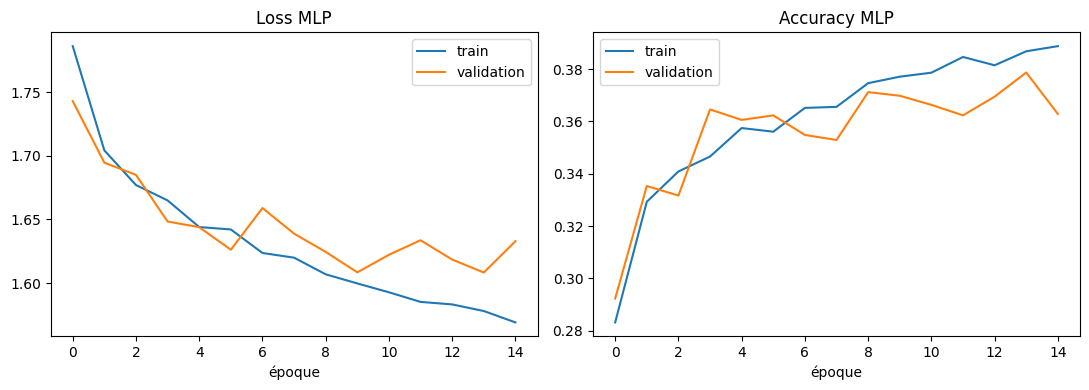

90/90 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - accuracy: 0.3628 - loss: 1.6328
MLP : accuracy validation = 0.3628


In [ ]:
#Affichage des courbes
import matplotlib.pyplot as plt

def plot_history(h, title=""):
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))

    ax[0].plot(h.history["loss"], label="train")
    ax[0].plot(h.history["val_loss"], label="validation")
    ax[0].set_title(f"Loss {title}")
    ax[0].set_xlabel("époque")
    ax[0].legend()

    ax[1].plot(h.history["accuracy"], label="train")
    ax[1].plot(h.history["val_accuracy"], label="validation")
    ax[1].set_title(f"Accuracy {title}")
    ax[1].set_xlabel("époque")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history_mlp, "MLP")

val_loss, val_acc = mlp.evaluate(val_dataset)
print(f"MLP : accuracy validation = {val_acc:.4f}")

Les loss d'entraînement et de validation baissent lentement et restent proches (époque 15 : 1,569 contre 1,633, accuracy 38,9 % contre 36,3 %). C'est du sous-apprentissage : le modèle est trop simple, car Flatten détruit la structure spatiale de l'image. Avec 36,3 % d'accuracy de validation, il fait à peine mieux qu'un modèle qui répondrait toujours « joie » (environ 25 % des images). Ce modèle sert de point de comparaison pour le CNN.

# Partie 3: Construction d’un CNN avec Keras

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

cnn = keras.Sequential([
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu", name="conv1"),
    layers.MaxPooling2D((2, 2), name="pool1"),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu", name="conv2"),
    layers.MaxPooling2D((2, 2), name="pool2"),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu", name="conv3"),
    layers.MaxPooling2D((2, 2), name="pool3"),

    layers.Flatten(name="flatten"),
    layers.Dense(128, activation="relu", name="dense"),
    layers.Dense(7, activation="softmax", name="sortie"),
], name="cnn_expressions")

cnn.summary()

Model: "cnn_expressions"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sortie (Dense)                  │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,527 (2.61 MB)

 Trainable params: 683,527 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

## Architecture proposée

Image (48×48×1) → [Conv2D(32) + ReLU → MaxPool] → [Conv2D(64) + ReLU → MaxPool] → [Conv2D(128) + ReLU → MaxPool] → Flatten → Dense(128) + ReLU → Dense(7) + Softmax

### Rôle de chaque couche

| Couche | Rôle |
|---|---|
| Conv2D (×3) | Réalise la convolution : des filtres 3×3 glissent sur l'image et produisent des feature maps, puis ReLU est appliquée. Les filtres sont appris pendant l'entraînement. |
| MaxPooling2D (×3) | Pooling 2×2 : dans chaque fenêtre, on garde la valeur maximale. |
| Flatten | Transforme les feature maps (6×6×128) en un vecteur de 4608 valeurs, car une couche Dense attend un vecteur. |
| Dense(128) | Combine les caractéristiques extraites par la partie convolutive pour décider de l'expression. |
| Dense(7) | 7 neurones car FER-2013 contient 7 classes ; Softmax donne une distribution de probabilités sur ces 7 classes. |
### Pourquoi ces choix ?

| Choix | Justification |
|---|---|
| Filtres : 32 → 64 → 128 | Chaque filtre détecte un motif.<br>• Premiers blocs : motifs simples (bords, contours), peu nombreux, donc 32 filtres suffisent.<br>• Derniers blocs : combinaisons de ces motifs (œil, bouche, sourcils), bien plus nombreuses, donc plus de filtres.<br>• Comme l'image est divisée par 2 à chaque pooling, on peut doubler les filtres sans faire grossir le volume de données (il est divisé par 2 à chaque bloc).<br>• Puissances de 2 : convention. |
| Kernel 3×3 | Plus petite fenêtre qui regarde les voisins dans toutes les directions : 9 poids par canal.<br>En empilant des couches, le champ de vision grandit : deux convolutions 3×3 voient la même zone qu'un 5×5, avec moins de paramètres (18 contre 25). |
| Stride 1 | Le filtre avance d'un pixel à la fois : aucune information perdue.<br>Un stride de 2 diviserait la taille de sortie par 2. |
| Padding « same » | Ajoute des zéros autour de l'image pour conserver la taille : (48 − 3 + 2) / 1 + 1 = 48.<br>Sans padding, on perdrait 2 pixels par convolution, ce qui est gênant sur des images de 48×48. |
| ReLU | max(0, z).<br>• Introduit la non-linéarité (sans elle, empiler des couches reviendrait à une seule opération linéaire).<br>• Simple à calculer.<br>• Sa dérivée vaut 1 pour z > 0, ce qui limite la disparition du gradient. |
| MaxPooling 2×2 | Dans chaque fenêtre 2×2, on garde la valeur maximale.<br>Hauteur et largeur divisées par 2 (48 → 24 → 12 → 6) : moins de calculs, et le réseau est moins sensible aux petits décalages du visage.<br>Aucun paramètre. |
| Flatten | Passe du volume 3D (6, 6, 128) à un vecteur de 6 × 6 × 128 = 4608 valeurs, car une couche Dense attend un vecteur. |
| Dense(128) | Même taille que le MLP de référence, pour une comparaison équitable.<br>Compromis : trop peu de neurones et les caractéristiques sont mal combinées, trop et le risque de surapprentissage augmente. |
| Dense(7) + Softmax | Un neurone par expression (7 classes).<br>Softmax donne 7 probabilités dont la somme vaut 1 : la classe prédite est celle de plus forte probabilité. |

### Dimensions et paramètres

| Couche | Dimension de sortie | Paramètres | Calcul |
|---|---|---|---|
| Entrée | (None, 48, 48, 1) | 0 | — |
| conv1 | (None, 48, 48, 32) | 320 | 32 × (3×3×1 + 1) |
| pool1 | (None, 24, 24, 32) | 0 | — |
| conv2 | (None, 24, 24, 64) | 18 496 | 64 × (3×3×32 + 1) |
| pool2 | (None, 12, 12, 64) | 0 | — |
| conv3 | (None, 12, 12, 128) | 73 856 | 128 × (3×3×64 + 1) |
| pool3 | (None, 6, 6, 128) | 0 | — |
| flatten | (None, 4608) | 0 | 6 × 6 × 128 |
| dense | (None, 128) | 589 952 | 4608 × 128 + 128 |
| sortie | (None, 7) | 903 | 128 × 7 + 7 |
| **Total** | | **683 527** | |

Le "None" correspond au nombre d'images du lot, qui n'est pas fixé. La taille spatiale est divisée par 2 à chaque pooling, tandis que le nombre de feature maps augmente (1 → 32 → 64 → 128). Les trois convolutions ne comptent que 92 672 paramètres, alors que la couche Dense(128) en concentre 589 952, soit environ 86 % du total : les filtres sont partagés sur toute l'image, donc la convolution coûte très peu de paramètres.

# Partie 4: Entraînement du réseau

Epoch 1/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 29s 63ms/step - accuracy: 0.3202 - loss: 1.6940 - val_accuracy: 0.4008 - val_loss: 1.5518
Epoch 2/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.4458 - loss: 1.4511 - val_accuracy: 0.4663 - val_loss: 1.3779
Epoch 3/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.4988 - loss: 1.3152 - val_accuracy: 0.5022 - val_loss: 1.3051
Epoch 4/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.5439 - loss: 1.2091 - val_accuracy: 0.5213 - val_loss: 1.2438
Epoch 5/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.5818 - loss: 1.1143 - val_accuracy: 0.5328 - val_loss: 1.2260
Epoch 6/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.6183 - loss: 1.0260 - val_accuracy: 0.5389 - val_loss: 1.2293
Epoch 7/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.6541 - loss: 0.9353 - val_accuracy: 0.5386 - val_loss: 1.2519
Epoch 8/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - accuracy: 0.6909 - loss: 0.8429 - 

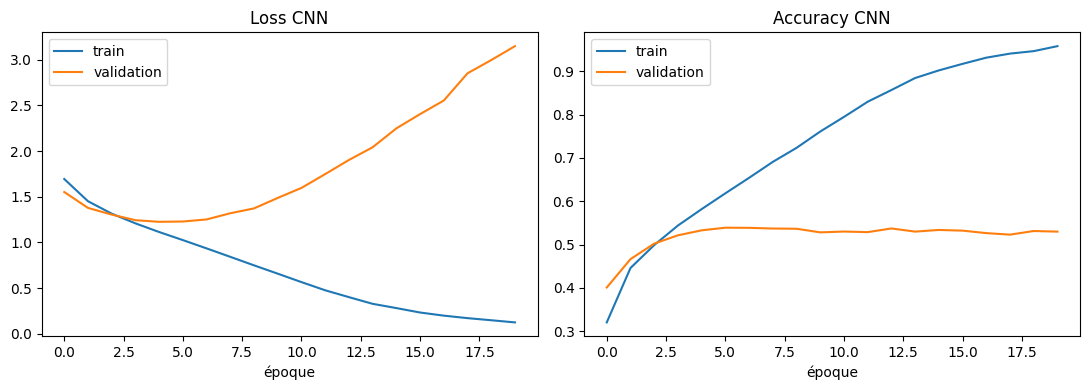

90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.5299 - loss: 3.1472
CNN : accuracy validation = 0.5299


In [ ]:
cnn.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

history_cnn = cnn.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20
)

plot_history(history_cnn, "CNN")

val_loss, val_acc = cnn.evaluate(val_dataset)
print(f"CNN : accuracy validation = {val_acc:.4f}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
cnn.save("/content/drive/MyDrive/model_cnn.keras")
print("Modèle CNN de base sauvegardé")

Mounted at /content/drive
Modèle CNN de base sauvegardé


### Interprétation des courbes

La loss d'entraînement diminue tout au long des 20 époques (jusqu'à 0,13) et l'accuracy d'entraînement atteint 95,8 %. Sur la validation, la loss ne baisse que jusqu'à l'époque 5, puis remonte jusqu'à 3,15 à la fin. L'accuracy de validation reste autour de 52-53 % sur les dernières époques (53,0 % à la fin). L'écart entre train et validation atteint environ 43 points : c'est un surapprentissage net à partir de l'époque 5. Le modèle ne généralise plus et apprend par cœur les images d'entraînement. Cela s'explique par le grand nombre de paramètres (683 527) par rapport au nombre d'images d'entraînement (environ 23 000), et par l'absence de technique pour limiter ce problème.

Le CNN reste pourtant meilleur que le MLP (53,0 % contre 36,3 % en validation) : la convolution exploite la structure spatiale de l'image.

Pour la partie 6, nous allons essayer de réduire ce surapprentissage avec l'Early Stopping, le Dropout et la Data Augmentation.

# Partie 5: Évaluation et analyse des erreurs

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


drive.mount('/content/drive')
mlp = keras.models.load_model("/content/drive/MyDrive/mlp.keras")
cnn = keras.models.load_model("/content/drive/MyDrive/model_cnn.keras")


# 1. ÉVALUATION GLOBALE
print("--- Évaluation globale sur le Test Dataset avec MLP ---")
test_mlp_loss, test_mlp_accuracy = mlp.evaluate(test_dataset)
print("--- Évaluation globale sur le Test Dataset avec CNN ---")
test_cnn_loss, test_cnn_accuracy = cnn.evaluate(test_dataset)
print(f"\nConclusion : Le CNN a amélioré l'accuracy de {(test_cnn_accuracy - test_mlp_accuracy)*100:.2f} points de pourcentage par rapport au réseau simple !")

# 2. PRÉDICTIONS
probas = cnn.predict(test_dataset)           # (5741, 7)
classes_predites = np.argmax(probas, axis=1) # (5741,)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Évaluation globale sur le Test Dataset avec MLP ---
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.3629 - loss: 1.6150
--- Évaluation globale sur le Test Dataset avec CNN ---
113/113 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step - accuracy: 0.5247 - loss: 3.1703

Conclusion : Le CNN a amélioré l'accuracy de 16.17 points de pourcentage par rapport au réseau simple !
113/113 ━━━━━━━━━━━━━━━━━━━━ 17s 140ms/step


In [ ]:
#Récupérer le test dataset pour la mettre dans la matrice de confusion
import numpy as np
import matplotlib.pyplot as plt

X_test, y_test = [], []
for images, labels in test_dataset:
    X_test.append(images.numpy())
    y_test.append(np.argmax(labels.numpy(), axis=1))
X_test = np.concatenate(X_test)
y_test = np.concatenate(y_test)
print(X_test.shape, y_test.shape)

#Evaluation
cnn.evaluate(test_dataset)

probas = cnn.predict(X_test)
classes = np.argmax(probas, axis=1)

print("Accuracy :", np.mean(classes == y_test))

(7178, 48, 48, 1) (7178,)
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.5247 - loss: 3.1703
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Accuracy : 0.5246586792978546


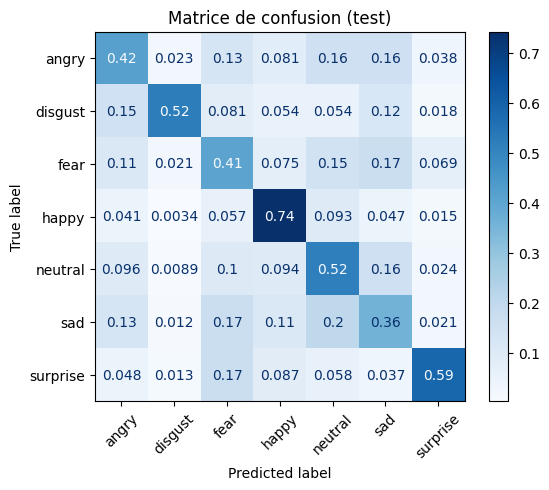

              precision    recall  f1-score   support

       angry      0.434     0.419     0.426       958
     disgust      0.400     0.523     0.453       111
        fear      0.372     0.407     0.389      1024
       happy      0.731     0.743     0.737      1774
     neutral      0.452     0.517     0.482      1233
         sad      0.408     0.357     0.381      1247
    surprise      0.718     0.588     0.647       831

    accuracy                          0.525      7178
   macro avg      0.502     0.508     0.502      7178
weighted avg      0.529     0.525     0.525      7178

« sad » prise pour « neutral » : 254 fois
« sad » prise pour « fear » : 209 fois
« neutral » prise pour « sad » : 195 fois


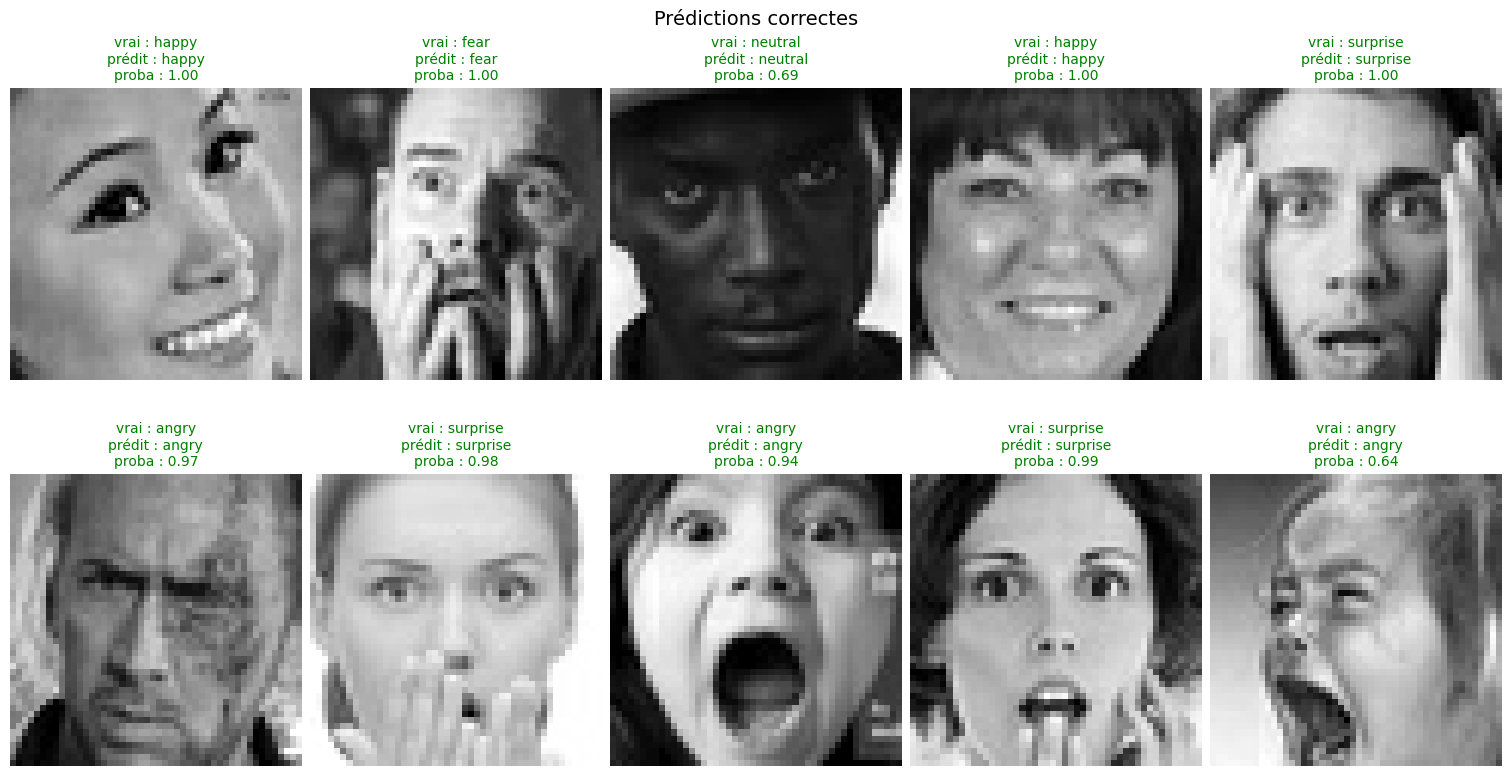

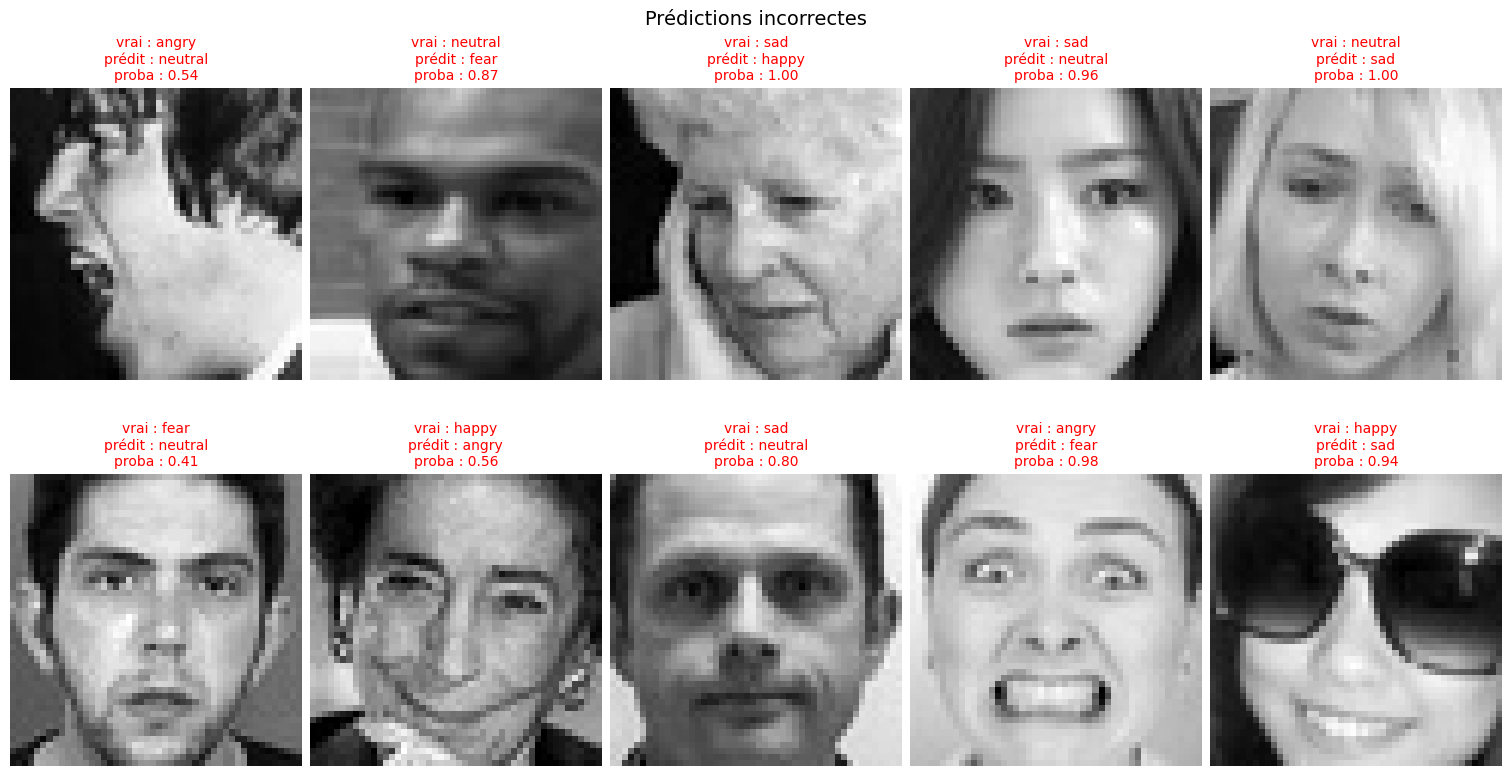

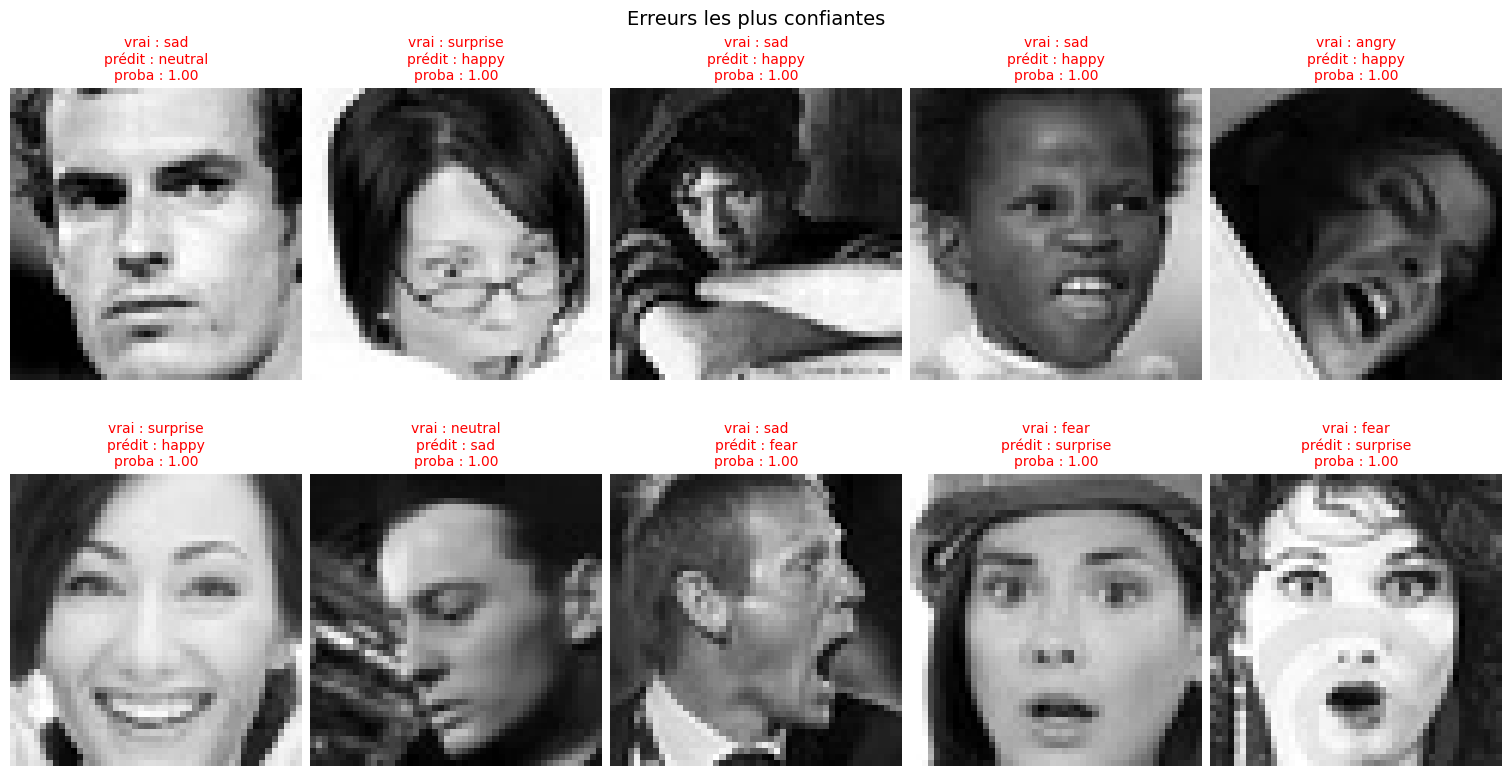

In [ ]:
#Matrice de confusion
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

ConfusionMatrixDisplay.from_predictions(
    y_test, classes,
    display_labels=class_names,
    normalize="true",          # chaque ligne est divisée par son total (proportions)
    cmap="Blues",
    xticks_rotation=45
)
plt.title("Matrice de confusion (test)")
plt.show()

print(classification_report(y_test, classes, target_names=class_names, digits=3))

#Affichage des confusions les plus fréquentes
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, classes)
np.fill_diagonal(cm, 0)                    # on garde seulement les erreurs
for _ in range(3):
    i, j = np.unravel_index(cm.argmax(), cm.shape)
    print(f"« {class_names[i]} » prise pour « {class_names[j]} » : {cm[i, j]} fois")
    cm[i, j] = 0



def afficher(indices, titre):
    fig, axes = plt.subplots(2, 5, figsize=(15, 8), constrained_layout=True)
    for ax, i in zip(axes.flat, indices):
        p = classes[i]
        ax.imshow(X_test[i].squeeze(), cmap="gray")
        ax.axis("off")
        ax.set_title(f"vrai : {class_names[y_test[i]]}\nprédit : {class_names[p]}\nproba : {probas[i, p]:.2f}",
                     color="green" if p == y_test[i] else "red", fontsize=10)
    fig.suptitle(titre, fontsize=14)
    plt.show()

justes  = np.where(classes == y_test)[0]
fausses = np.where(classes != y_test)[0]

afficher(np.random.choice(justes, 10, replace=False), "Prédictions correctes")
afficher(np.random.choice(fausses, 10, replace=False), "Prédictions incorrectes")

# Les erreurs où le modèle était le plus sûr de lui
confiance = probas.max(axis=1)
afficher(fausses[np.argsort(-confiance[fausses])][:10], "Erreurs les plus confiantes")

## Évaluation du CNN de base (jeu de test)

Sur le jeu de test (7 178 images), le CNN de base obtient 52,5 % d'accuracy, contre 36,3 % pour le MLP. Il gagne donc 16 points. Sa loss de test est de 3,17, ce qui confirme le surapprentissage vu en partie 4.

### Analyse

***Expressions bien reconnues.*** Happy (recall 74,3 %, F1 0,737) et surprise (recall 58,8 %, F1 0,647) sont les mieux reconnues. Ce sont des expressions aux traits marqués (sourire, bouche ouverte, yeux écarquillés), visibles même en 48×48. Neutral (51,7 %) est proche de l'accuracy globale.

***Expressions confondues.*** Sad est prise pour neutral 254 fois (20 % des sad) et pour fear 209 fois (17 %). Neutral est aussi prise pour sad 195 fois (16 %). La matrice montre en plus que angry est souvent confondue avec neutral et sad (16 % chacune), et que surprise est prise pour fear dans 17 % des cas.

***Classes difficiles.*** Sad est la pire (recall 35,7 %, F1 0,381), alors que ce n'est pas une petite classe (4 830 images en train). L'expression est subtile, proche du neutre, et change beaucoup d'un visage à l'autre. Fear est aussi difficile (recall 40,7 %, F1 0,389) : elle est confondue avec sad (17 %), neutral (15 %) et angry (11 %). Disgust a un recall de 52,3 % malgré ses 436 images, mais ce chiffre est peu fiable. Il repose sur seulement 111 images de test, et la précision de cette classe est basse (0,400).

***Analyse des erreurs.*** Le CNN se trompe sur environ 3 400 images sur 7 178. Les 10 erreurs les plus confiantes ont toutes une probabilité de 1,00. C'est typique d'un modèle surappris (loss de test de 3,17) : il se trompe avec certitude. Plusieurs de ces erreurs semblent venir des labels. Par exemple, une femme qui sourit largement est étiquetée surprise et le modèle prédit happy, ce qui paraît juste. FER-2013 est connu pour ses labels bruités. On voit aussi des visages de profil ou penchés, des images sombres, et deux visages bouche ouverte et yeux écarquillés étiquetés fear que le modèle prend pour surprise. Ces deux expressions se ressemblent beaucoup. Parmi les autres erreurs, il y a des occlusions (lunettes de soleil, main sur le visage) et des visages neutres ou tristes presque impossibles à distinguer.

# Partie 6: Expérimentation et amélioration (≥ 3 expériences)

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

def build_cnn(dropout=0.0, augmentation=False, nom="cnn"):
    keras.utils.set_random_seed(42)
    model = keras.Sequential(name=nom)
    model.add(layers.Input(shape=(48, 48, 1)))
    if augmentation:                                   # actif seulement pendant l'entraînement
        model.add(layers.RandomFlip("horizontal"))
        model.add(layers.RandomRotation(0.04))         # ≈ ±14°
        model.add(layers.RandomZoom(0.1))
    for f in (32, 64, 128):
        model.add(layers.Conv2D(f, (3, 3), padding="same", activation="relu"))
        model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation="relu"))
    if dropout > 0:
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(7, activation="softmax"))
    return model

results = {}

# E0 : le CNN de base déjà entraîné (valeurs de la DERNIÈRE époque, sans Early Stopping)
h = history_cnn.history
results["E0 — CNN de base"] = {
    "epoques": len(h["loss"]), "meilleure": int(np.argmin(h["val_loss"])) + 1,
    "train_acc": h["accuracy"][-1], "val_acc": h["val_accuracy"][-1], "val_loss": h["val_loss"][-1]}

def run_experiment(nom, model, max_epochs=40, patience=5, class_weight=None, lr=1e-3):
    model.compile(loss="categorical_crossentropy", optimizer=Adam(learning_rate=lr), metrics=["accuracy"])
    early_stop = EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)
    history = model.fit(train_dataset, validation_data=val_dataset,
                        epochs=max_epochs, callbacks=[early_stop],
                        class_weight=class_weight, verbose=2)
    h = history.history
    b = int(np.argmin(h["val_loss"]))
    results[nom] = {"epoques": len(h["loss"]), "meilleure": b + 1,
                    "train_acc": h["accuracy"][b], "val_acc": h["val_accuracy"][b], "val_loss": h["val_loss"][b]}
    plot_history(history, nom)
    return history

Epoch 1/40
359/359 - 20s - 56ms/step - accuracy: 0.3267 - loss: 1.6887 - val_accuracy: 0.4151 - val_loss: 1.5322
Epoch 2/40
359/359 - 14s - 40ms/step - accuracy: 0.4388 - loss: 1.4606 - val_accuracy: 0.4651 - val_loss: 1.3814
Epoch 3/40
359/359 - 22s - 61ms/step - accuracy: 0.4989 - loss: 1.3170 - val_accuracy: 0.4914 - val_loss: 1.3337
Epoch 4/40
359/359 - 33s - 93ms/step - accuracy: 0.5424 - loss: 1.2148 - val_accuracy: 0.5095 - val_loss: 1.2728
Epoch 5/40
359/359 - 14s - 40ms/step - accuracy: 0.5772 - loss: 1.1249 - val_accuracy: 0.5182 - val_loss: 1.2689
Epoch 6/40
359/359 - 14s - 40ms/step - accuracy: 0.6095 - loss: 1.0491 - val_accuracy: 0.5344 - val_loss: 1.2389
Epoch 7/40
359/359 - 14s - 39ms/step - accuracy: 0.6454 - loss: 0.9644 - val_accuracy: 0.5374 - val_loss: 1.2623
Epoch 8/40
359/359 - 15s - 41ms/step - accuracy: 0.6776 - loss: 0.8880 - val_accuracy: 0.5273 - val_loss: 1.3140
Epoch 9/40
359/359 - 14s - 40ms/step - accuracy: 0.7059 - loss: 0.8065 - val_accuracy: 0.5313 - 

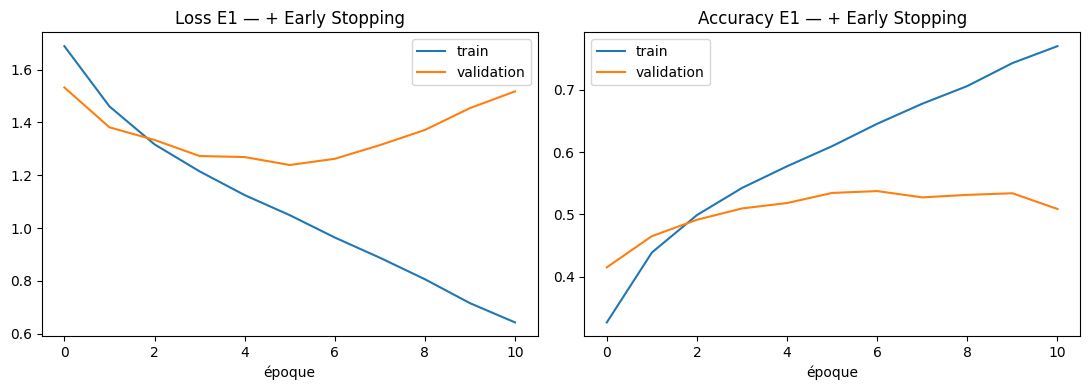

In [ ]:
#E1, Early Stopping seul
model_e1 = build_cnn(nom="cnn_e1")
h_e1 = run_experiment("E1 — + Early Stopping", model_e1)

Epoch 1/40
359/359 - 23s - 63ms/step - accuracy: 0.2965 - loss: 1.7482 - val_accuracy: 0.4039 - val_loss: 1.5848
Epoch 2/40
359/359 - 14s - 40ms/step - accuracy: 0.3973 - loss: 1.5557 - val_accuracy: 0.4473 - val_loss: 1.4474
Epoch 3/40
359/359 - 15s - 41ms/step - accuracy: 0.4419 - loss: 1.4497 - val_accuracy: 0.4771 - val_loss: 1.3710
Epoch 4/40
359/359 - 14s - 40ms/step - accuracy: 0.4774 - loss: 1.3671 - val_accuracy: 0.5029 - val_loss: 1.3269
Epoch 5/40
359/359 - 15s - 41ms/step - accuracy: 0.5023 - loss: 1.3035 - val_accuracy: 0.5032 - val_loss: 1.3044
Epoch 6/40
359/359 - 15s - 41ms/step - accuracy: 0.5259 - loss: 1.2498 - val_accuracy: 0.5165 - val_loss: 1.2628
Epoch 7/40
359/359 - 15s - 42ms/step - accuracy: 0.5478 - loss: 1.1931 - val_accuracy: 0.5281 - val_loss: 1.2464
Epoch 8/40
359/359 - 14s - 40ms/step - accuracy: 0.5687 - loss: 1.1430 - val_accuracy: 0.5250 - val_loss: 1.2541
Epoch 9/40
359/359 - 15s - 42ms/step - accuracy: 0.5845 - loss: 1.0908 - val_accuracy: 0.5227 - 

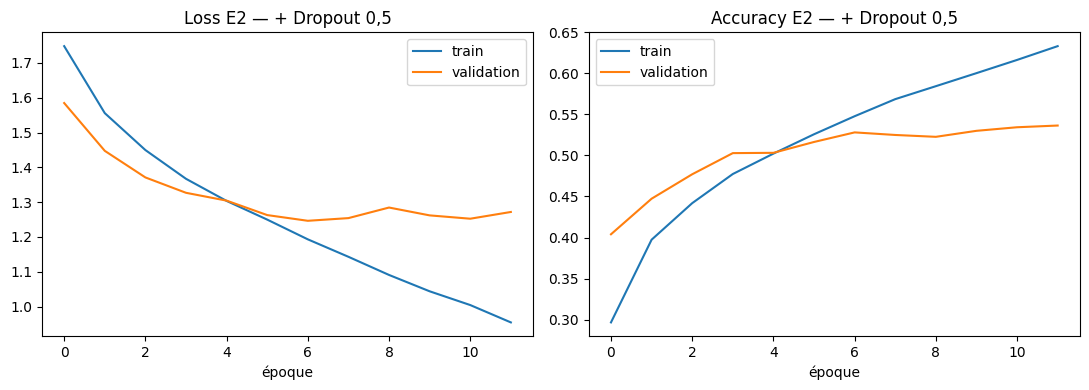

In [ ]:
#E2, + Dropout
model_e2 = build_cnn(dropout=0.5, nom="cnn_e2")
h_e2 = run_experiment("E2 — + Dropout 0,5", model_e2)

Epoch 1/40
359/359 - 22s - 62ms/step - accuracy: 0.2541 - loss: 1.8059 - val_accuracy: 0.2956 - val_loss: 1.7208
Epoch 2/40
359/359 - 15s - 42ms/step - accuracy: 0.3221 - loss: 1.6934 - val_accuracy: 0.3930 - val_loss: 1.5728
Epoch 3/40
359/359 - 15s - 43ms/step - accuracy: 0.3814 - loss: 1.5926 - val_accuracy: 0.4403 - val_loss: 1.4701
Epoch 4/40
359/359 - 15s - 41ms/step - accuracy: 0.4144 - loss: 1.5116 - val_accuracy: 0.4647 - val_loss: 1.3813
Epoch 5/40
359/359 - 15s - 42ms/step - accuracy: 0.4415 - loss: 1.4545 - val_accuracy: 0.4839 - val_loss: 1.3443
Epoch 6/40
359/359 - 15s - 41ms/step - accuracy: 0.4603 - loss: 1.4129 - val_accuracy: 0.4799 - val_loss: 1.3371
Epoch 7/40
359/359 - 15s - 42ms/step - accuracy: 0.4786 - loss: 1.3770 - val_accuracy: 0.5008 - val_loss: 1.2883
Epoch 8/40
359/359 - 15s - 41ms/step - accuracy: 0.4884 - loss: 1.3489 - val_accuracy: 0.5208 - val_loss: 1.2557
Epoch 9/40
359/359 - 15s - 41ms/step - accuracy: 0.4901 - loss: 1.3351 - val_accuracy: 0.5186 - 

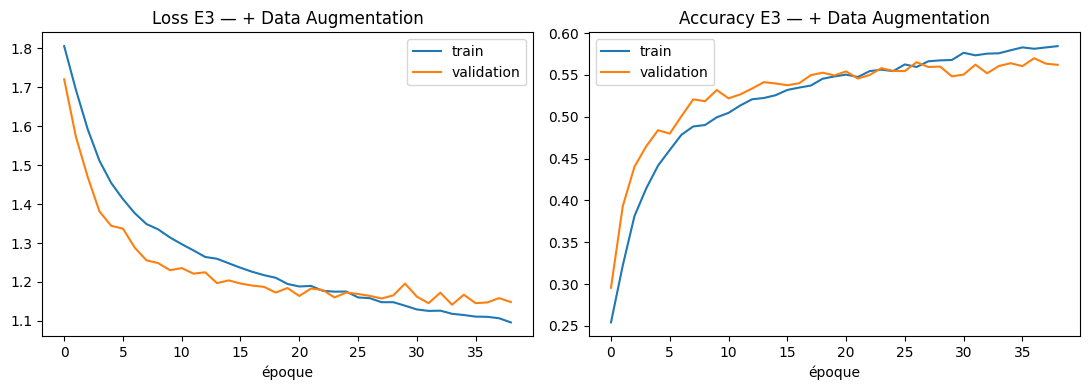

In [ ]:
#E3, + Data Augmentation
model_e3 = build_cnn(dropout=0.5, augmentation=True, nom="cnn_e3")
h_e3 = run_experiment("E3 — + Data Augmentation", model_e3)

In [ ]:
# Affichage des en-têtes avec des largeurs fixes
print(f"{'Expérience':<25} | {'Époques':<8} | {'Meilleure':<16} | {'Acc. train':<10} | {'Acc. val':<10} | {'Loss val':<10}")
print("-" * 93)

# Affichage des lignes
for nom, r in results.items():
    print(
        f"{nom:<25} | "
        f"{r['epoques']:<8} | "
        f"{r['meilleure']:<16} | "
        f"{r['train_acc']:<10.3f} | "
        f"{r['val_acc']:<10.3f} | "
        f"{r['val_loss']:<10.3f}"
    )

Expérience                | Époques  | Meilleure        | Acc. train | Acc. val   | Loss val  
---------------------------------------------------------------------------------------------
E0 — CNN de base          | 20       | 5                | 0.958      | 0.530      | 3.147     
E1 — + Early Stopping     | 11       | 6                | 0.609      | 0.534      | 1.239     
E2 — + Dropout 0,5        | 12       | 7                | 0.548      | 0.528      | 1.246     
E3 — + Data Augmentation  | 39       | 34               | 0.576      | 0.561      | 1.142     


In [ ]:

model_e3.save("/content/drive/MyDrive/model_e3.keras")
print("model_e3 sauvegardé")
model_e1.save("/content/drive/MyDrive/model_e1.keras")
model_e2.save("/content/drive/MyDrive/model_e2.keras")

model_e3 sauvegardé


## Expériences et amélioration du modèle

Chaque expérience ajoute une seule modification à la précédente, afin de pouvoir interpréter son effet.

| Expérience | Modification | Résultats (validation) | Observations |
|---|---|---|---|
| **E0** | CNN de base<br>20 époques | • acc. val : 53,0 %<br>• loss val : 3,15<br>(dernière époque) | • Surapprentissage marqué<br>• acc. train : 95,8 %<br>• Écart de ≈ 43 pts<br>• Meilleure époque : la 5, ensuite la loss de validation remonte |
| **E1** | + Early Stopping<br>(patience 5) | • acc. val : 53,4 %<br>• loss val : 1,239<br>• meilleure époque : 6<br>• arrêt à l'époque 11 | • Évite la dérive de la loss (3,15 → 1,24) en restaurant les meilleurs poids<br>• Surapprentissage encore présent : acc. train 60,9 %, écart de 7,5 pts |
| **E2** | + Dropout 0,5<br>après Dense(128) | • acc. val : 52,8 %<br>• loss val : 1,246<br>• meilleure époque : 7<br>• arrêt à l'époque 12 | • Écart train/val réduit à 2,0 pts (54,8 % contre 52,8 %)<br>• Pas de gain sur la validation (52,8 % contre 53,4 % pour E1), la différence est trop petite pour être sûre |
| **E3** | + Data Augmentation<br>(miroir, rotation ±14°, zoom 10 %) | • acc. val : 56,1 %<br>• loss val : 1,142<br>• meilleure époque : 34<br>• arrêt à l'époque 39 | • Meilleure acc. val et meilleure loss val<br>• Gain de plus de 3 points par rapport à E2<br>• Écart train/val de 1,5 pt (57,6 % contre 56,1 %), le surapprentissage a quasiment disparu |

### Choix du modèle final

Nous retenons **E3** : c'est le modèle qui a la meilleure accuracy de validation (56,1 %) et la loss de validation la plus basse (1,142). Son écart entre entraînement et validation est aussi le plus faible (1,5 point). Entre E1 et E2, la différence est de moins de 1 point, ce qui peut venir du hasard de l'initialisation. En revanche, la Data Augmentation apporte plus de 3 points par rapport à E2, et la loss de validation passe de 3,15 (E0) à 1,14. Le surapprentissage a presque disparu. Chaque expérience n'a été lancée qu'une seule fois, donc on ne peut pas mesurer la part du hasard. Le choix est fait avec la validation, pas avec le test. L'accuracy sur le jeu de test (56,6 %) est proche de celle de validation, donc le modèle généralise bien.


In [ ]:
from google.colab import drive
from tensorflow import keras

drive.mount('/content/drive')
model_e3 = keras.models.load_model("/content/drive/MyDrive/model_e3.keras")

final_model = model_e3
val_loss, val_acc = final_model.evaluate(val_dataset)
print(f"Modèle final : accuracy validation = {val_acc:.4f}")

final_model.save("/content/drive/MyDrive/cnn_final.keras")

test_loss, test_acc = final_model.evaluate(test_dataset)
print(f"Accuracy sur le TEST : {test_acc:.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.5607 - loss: 1.1417
Modèle final : accuracy validation = 0.5607
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.5658 - loss: 1.1343
Accuracy sur le TEST : 0.5658


# Partie 7: Enrichissement avec les nouvelles notions du cours

Deux idées pour aller plus loin, en partant de E3 (le meilleur CNN de la partie 6).

**E4 : poids de classes.** Disgust n'a que 436 images contre 7 215 pour Happy. Le modèle voit très peu cette classe et peut l'ignorer sans que la loss augmente beaucoup. Avec `class_weight`, une erreur sur une image d'une classe rare compte plus dans la loss.

**E5 : transfer learning.** On réutilise MobileNetV2, un réseau déjà entraîné sur ImageNet (plus d'un million d'images). Ses premières couches savent déjà détecter des bords et des textures. Comme il attend des images en couleur de taille plus grande, ces étapes sont ajoutées **dans le modèle** : agrandissement 48 → 96, copie du canal gris sur 3 canaux, valeurs entre -1 et 1. L'entrée du modèle reste donc une image 48×48×1 avec des pixels entre 0 et 1, comme pour les autres modèles. Cela simplifie la partie 8.
L'entraînement se fait en 2 temps : d'abord seule la nouvelle tête (Dense) apprend, puis on débloque les dernières couches de MobileNetV2 avec un très petit learning rate (fine-tuning).

Comme les classes sont déséquilibrées, on compare les modèles avec l'accuracy, le **F1 macro** (moyenne des F1 de chaque classe, toutes les classes comptent pareil) et le recall de Disgust.

{'angry': 1.02, 'disgust': 9.04, 'fear': 1.0, 'happy': 0.56, 'neutral': 0.83, 'sad': 0.86, 'surprise': 1.32}
Epoch 1/40
359/359 - 18s - 50ms/step - accuracy: 0.1771 - loss: 1.9389 - val_accuracy: 0.2466 - val_loss: 1.8539
Epoch 2/40
359/359 - 17s - 48ms/step - accuracy: 0.2463 - loss: 1.8333 - val_accuracy: 0.3026 - val_loss: 1.7525
Epoch 3/40
359/359 - 25s - 70ms/step - accuracy: 0.2801 - loss: 1.7725 - val_accuracy: 0.3498 - val_loss: 1.7182
Epoch 4/40
359/359 - 16s - 45ms/step - accuracy: 0.3109 - loss: 1.7245 - val_accuracy: 0.3564 - val_loss: 1.6675
Epoch 5/40
359/359 - 16s - 45ms/step - accuracy: 0.3378 - loss: 1.6774 - val_accuracy: 0.3733 - val_loss: 1.6109
Epoch 6/40
359/359 - 26s - 71ms/step - accuracy: 0.3578 - loss: 1.6315 - val_accuracy: 0.4038 - val_loss: 1.5363
Epoch 7/40
359/359 - 34s - 94ms/step - accuracy: 0.3787 - loss: 1.5911 - val_accuracy: 0.4437 - val_loss: 1.4498
Epoch 8/40
359/359 - 16s - 44ms/step - accuracy: 0.3861 - loss: 1.5604 - val_accuracy: 0.4376 - val_

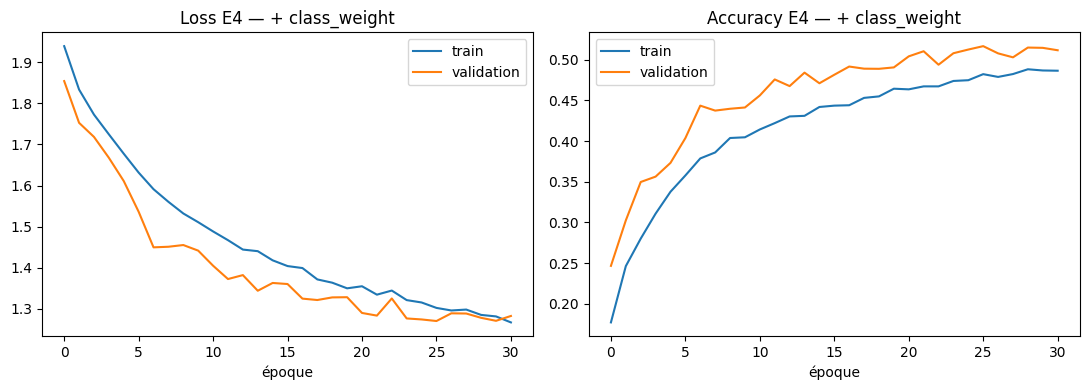

In [ ]:
from sklearn.metrics import f1_score, recall_score
from sklearn.utils.class_weight import compute_class_weight

# Accuracy, F1 macro et recall de Disgust sur la validation
def evaluer_val(model, nom):
    p = np.argmax(model.predict(X_val, verbose=0), axis=1)
    idx_disgust = [n.lower() for n in class_names].index("disgust")
    return {"nom": nom,
            "val_acc": float(np.mean(p == y_val)),
            "f1_macro": f1_score(y_val, p, average="macro"),
            "recall_disgust": recall_score(y_val, p, labels=[idx_disgust], average=None)[0]}

# Labels du jeu d'entraînement, puis poids "balanced" : n_images / (n_classes * n_images_de_la_classe)
y_train = np.concatenate([np.argmax(l.numpy(), axis=1) for _, l in train_dataset])
poids = compute_class_weight("balanced", classes=np.arange(7), y=y_train)
class_weights = {i: float(w) for i, w in enumerate(poids)}
print({class_names[i]: round(w, 2) for i, w in class_weights.items()})

# E4 : même modèle que E3, avec les poids de classes
model_e4 = build_cnn(dropout=0.5, augmentation=True, nom="cnn_e4")
h_e4 = run_experiment("E4 — + class_weight", model_e4, class_weight=class_weights)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/15
359/359 - 24s - 67ms/step - accuracy: 0.3275 - loss: 1.8610 - val_accuracy: 0.3987 - val_loss: 1.5948
Epoch 2/15
359/359 - 21s - 58ms/step - accuracy: 0.3943 - loss: 1.5906 - val_accuracy: 0.4018 - val_loss: 1.5564
Epoch 3/15
359/359 - 41s - 113ms/step - accuracy: 0.4131 - loss: 1.5370 - val_accuracy: 0.4200 - val_loss: 1.5284
Epoch 4/15
359/359 - 20s - 56ms/step - accuracy: 0.4249 - loss: 1.5104 - val_accuracy: 0.4341 - val_loss: 1.4871
Epoch 5/15
359/359 - 21s - 59ms/step - accuracy: 0.4273 - loss: 1.5010 - val_accuracy: 0.4132 - val_loss: 1.5168
Epoch 6/15
359/359 - 39s - 108ms/step - accuracy: 0.4262 - loss: 1.4946 - val_accuracy: 0.4137 - val_loss: 1.5014
Epoch 7/15
359/359 - 21s - 59ms/step - accuracy: 0.4259 - loss: 1.4975 - val_accuracy: 0.4182 - val_loss: 1.5045


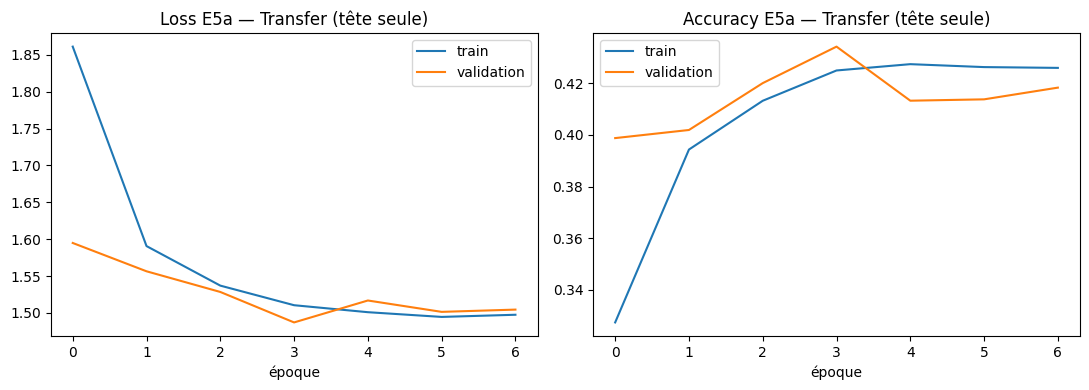

In [ ]:
from tensorflow.keras.applications import MobileNetV2

def build_transfer(nom="mobilenet_fer"):
    keras.utils.set_random_seed(42)
    entree = layers.Input(shape=(48, 48, 1))
    x = layers.RandomFlip("horizontal")(entree)          # même augmentation que E3
    x = layers.RandomRotation(0.04)(x)
    x = layers.RandomZoom(0.1)(x)
    x = layers.Resizing(96, 96)(x)                       # 48x48 -> 96x96
    x = layers.Concatenate()([x, x, x])                  # gris -> 3 canaux
    x = layers.Rescaling(2.0, offset=-1.0)(x)            # [0, 1] -> [-1, 1] (attendu par MobileNetV2)
    base = MobileNetV2(input_shape=(96, 96, 3), include_top=False, weights="imagenet")
    base.trainable = False                               # temps 1 : on gèle MobileNetV2
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    sortie = layers.Dense(7, activation="softmax")(x)
    return keras.Model(entree, sortie, name=nom), base

model_tl, base_tl = build_transfer()

# Temps 1 : seule la nouvelle tête apprend
h_tl1 = run_experiment("E5a — Transfer (tête seule)", model_tl, max_epochs=15, patience=3)

Epoch 1/20
359/359 - 34s - 94ms/step - accuracy: 0.4509 - loss: 1.4448 - val_accuracy: 0.4329 - val_loss: 1.4665
Epoch 2/20
359/359 - 17s - 48ms/step - accuracy: 0.4708 - loss: 1.3921 - val_accuracy: 0.4492 - val_loss: 1.4358
Epoch 3/20
359/359 - 17s - 48ms/step - accuracy: 0.4841 - loss: 1.3540 - val_accuracy: 0.4609 - val_loss: 1.4034
Epoch 4/20
359/359 - 20s - 55ms/step - accuracy: 0.5015 - loss: 1.3217 - val_accuracy: 0.4672 - val_loss: 1.3914
Epoch 5/20
359/359 - 18s - 51ms/step - accuracy: 0.5046 - loss: 1.3025 - val_accuracy: 0.4734 - val_loss: 1.3731
Epoch 6/20
359/359 - 18s - 49ms/step - accuracy: 0.5094 - loss: 1.2814 - val_accuracy: 0.4795 - val_loss: 1.3629
Epoch 7/20
359/359 - 17s - 48ms/step - accuracy: 0.5245 - loss: 1.2605 - val_accuracy: 0.4835 - val_loss: 1.3509
Epoch 8/20
359/359 - 17s - 48ms/step - accuracy: 0.5292 - loss: 1.2436 - val_accuracy: 0.4846 - val_loss: 1.3529
Epoch 9/20
359/359 - 17s - 47ms/step - accuracy: 0.5349 - loss: 1.2307 - val_accuracy: 0.4935 - 

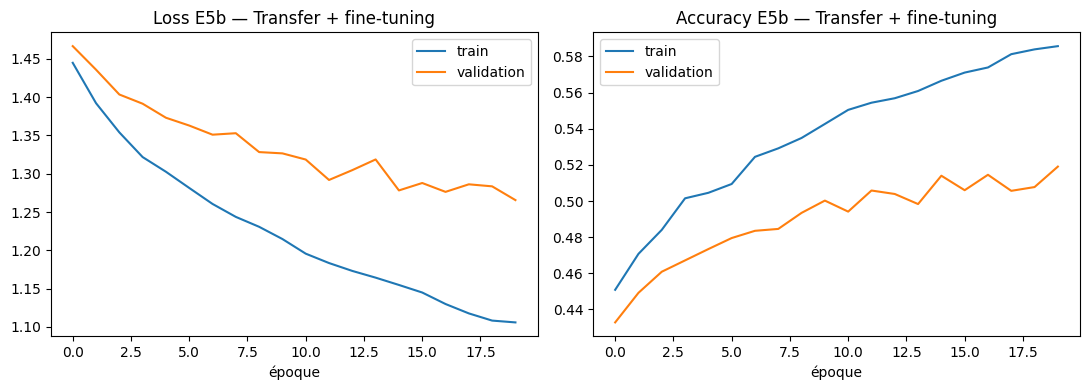

In [ ]:
# Temps 2 : fine-tuning. On débloque les 30 dernières couches de MobileNetV2,
# mais on laisse les couches BatchNormalization gelées. Learning rate très petit.
base_tl.trainable = True
for couche in base_tl.layers[:-30]:
    couche.trainable = False
for couche in base_tl.layers:
    if isinstance(couche, layers.BatchNormalization):
        couche.trainable = False

h_tl2 = run_experiment("E5b — Transfer + fine-tuning", model_tl, max_epochs=20, patience=4, lr=1e-5)

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

model_e4.save("/content/drive/MyDrive/model_e4.keras")
model_tl.save("/content/drive/MyDrive/model_e5.keras")
print("model_e4 et model_e5 sauvegardés")

Mounted at /content/drive
model_e4 et model_e5 sauvegardés


In [ ]:
import numpy as np

def dataset_vers_tableaux(ds):
    X, y = [], []
    for images, labels in ds:
        X.append(images.numpy())
        y.append(np.argmax(labels.numpy(), axis=1))
    return np.concatenate(X), np.concatenate(y)

X_test, y_test = dataset_vers_tableaux(test_dataset)
X_val, y_val = dataset_vers_tableaux(val_dataset)
print("test :", X_test.shape, "| val :", X_val.shape)

test : (7178, 48, 48, 1) | val : (5741, 48, 48, 1)


In [ ]:
import pandas as pd

# Les trois candidats pour le modèle final (tous avec une entrée 48x48x1 entre 0 et 1)
candidats = {
    "E3 — CNN (partie 6)": model_e3,
    "E4 — + class_weight": model_e4,
    "E5b — Transfer + fine-tuning": model_tl,
}
comp = [evaluer_val(m, n) for n, m in candidats.items()]
tab = pd.DataFrame(comp).set_index("nom")
tab.columns = ["Acc. val", "F1 macro", "Recall disgust"]
display(tab.round(3))

# Rappel de toutes les expériences (meilleure époque)
display(pd.DataFrame(results).T.round(3))

,Acc. val,F1 macro,Recall disgust
nom,,,
E3 — CNN (partie 6),0.561,0.481,0.055
E4 — + class_weight,0.517,0.461,0.740
E5b — Transfer + fine-tuning,0.519,0.465,0.110


,epoques,meilleure,train_acc,val_acc,val_loss
E0 — CNN de base,20.0,5.0,0.958,0.530,3.147
E1 — + Early Stopping,11.0,6.0,0.609,0.534,1.239
"E2 — + Dropout 0,5",12.0,7.0,0.548,0.528,1.246
E3 — + Data Augmentation,39.0,34.0,0.576,0.561,1.142
E4 — + class_weight,31.0,26.0,0.482,0.517,1.271
E5a — Transfer (tête seule),7.0,4.0,0.425,0.434,1.487
E5b — Transfer + fine-tuning,20.0,20.0,0.586,0.519,1.266


| Expérience | Modification | Acc. val | F1 macro | Recall Disgust | Observations |
|---|---|---|---|---|---|
| **E3** | CNN + Dropout + Data Augmentation | 56,1 % | 0,481 | 5,5 % | Point de départ. Disgust n'est presque jamais reconnue |
| **E4** | E3 + poids de classes | 51,7 % | 0,461 | 74,0 % | Disgust est bien mieux reconnue, mais l'accuracy baisse de 4,4 points |
| **E5b** | MobileNetV2 + fine-tuning | 51,9 % | 0,465 | 11,0 % | Moins bon que E3 sur tous les points |

**Discussion.** Avec les poids de classes (E4), le recall de Disgust passe de 5,5 % à 74 %, mais l'accuracy et le F1 macro baissent. Le modèle prédit sans doute Disgust trop souvent, au détriment des autres classes. Le transfer learning (E5b) n'aide pas ici. Les images FER-2013 sont petites (48×48) et en niveaux de gris, très différentes des images en couleur d'ImageNet. La phase 1, avec la tête seule, donne seulement 43,4 %, et le fine-tuning remonte à 51,9 %. Sa meilleure époque est la dernière (20 sur 20), donc l'entraînement n'était pas fini et le résultat pourrait encore monter avec plus d'époques. Nous ne l'avons pas testé.

Modèle final : E3 — CNN (partie 6)
TEST : loss = 1.134 | accuracy = 0.5658
              precision    recall  f1-score   support

       angry      0.464     0.479     0.471       958
     disgust      1.000     0.099     0.180       111
        fear      0.380     0.329     0.353      1024
       happy      0.743     0.830     0.784      1774
     neutral      0.508     0.583     0.543      1233
         sad      0.449     0.420     0.434      1247
    surprise      0.740     0.649     0.691       831

    accuracy                          0.566      7178
   macro avg      0.612     0.484     0.494      7178
weighted avg      0.566     0.566     0.559      7178



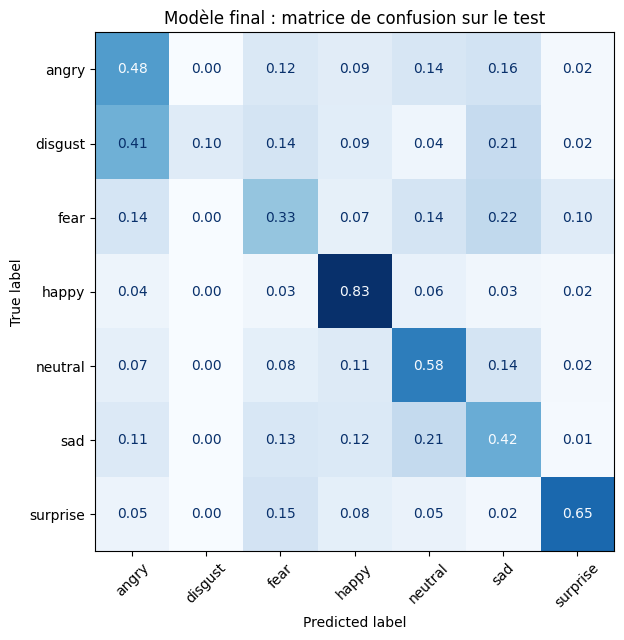

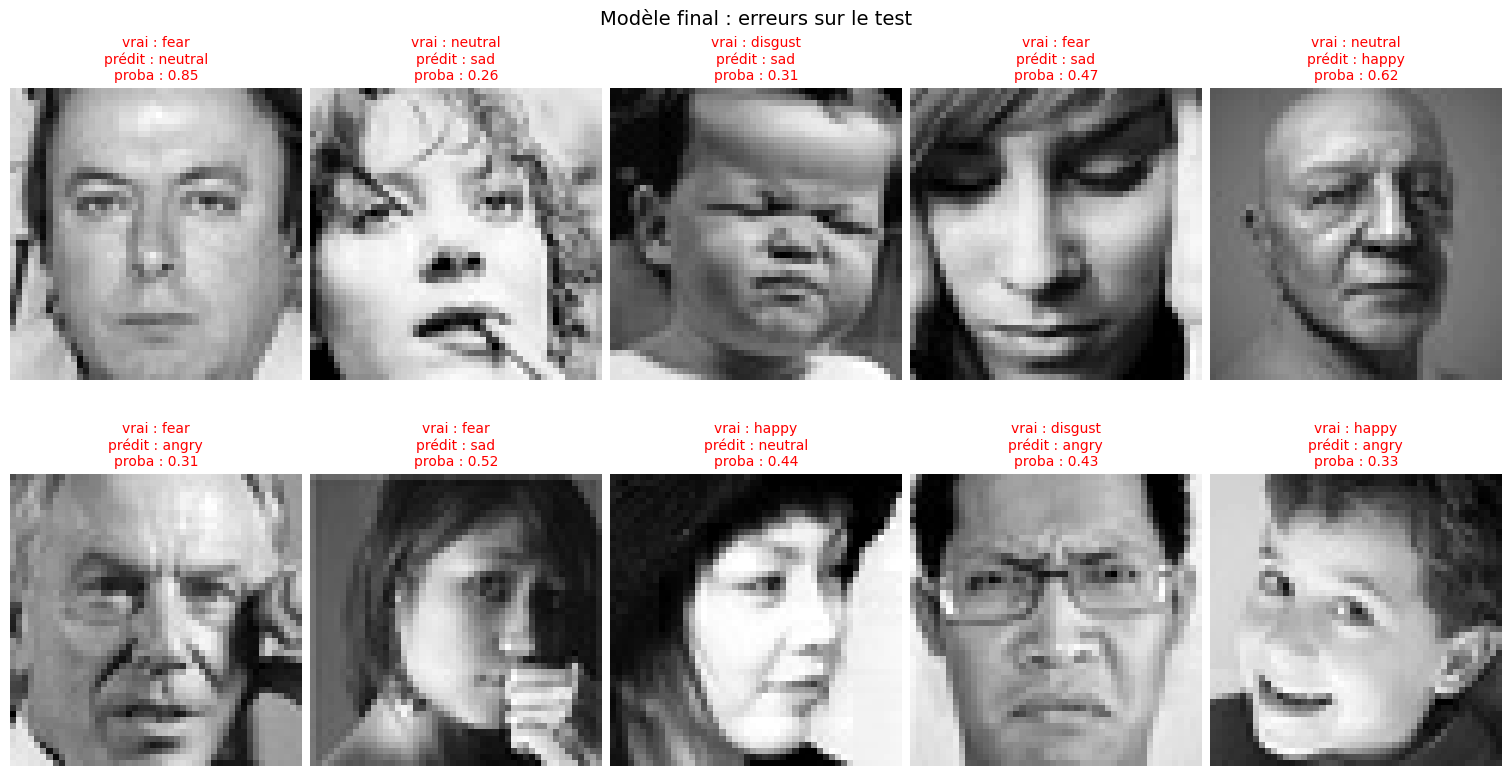

Modèle final sauvegardé


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

# Affiche 10 images avec vraie classe, classe prédite et probabilité
def afficher_predictions(indices, titre, X, y_vrai, y_pred, probas):
    fig, axes = plt.subplots(2, 5, figsize=(15, 8), constrained_layout=True)
    for ax, i in zip(axes.flat, indices):
        p = y_pred[i]
        ax.imshow(X[i].squeeze(), cmap="gray")
        ax.axis("off")
        ax.set_title(f"vrai : {class_names[y_vrai[i]]}\nprédit : {class_names[p]}\nproba : {probas[i, p]:.2f}",
                     color="green" if p == y_vrai[i] else "red", fontsize=10)
    fig.suptitle(titre, fontsize=14)
    plt.show()

# Choix du modèle final : meilleur F1 macro sur la VALIDATION (classes déséquilibrées).
nom_final = tab["F1 macro"].idxmax()
final_model = candidats[nom_final]
print("Modèle final :", nom_final)

# Évaluation sur le TEST : une seule fois, sur le modèle final
test_loss, test_acc = final_model.evaluate(test_dataset, verbose=0)
print(f"TEST : loss = {test_loss:.3f} | accuracy = {test_acc:.4f}")

# Images et labels du test récupérés dans le même passage
X_test, y_test = [], []
for images, labels in test_dataset:
    X_test.append(images.numpy())
    y_test.append(np.argmax(labels.numpy(), axis=1))
X_test = np.concatenate(X_test)
y_test = np.concatenate(y_test)

probas_test = final_model.predict(X_test, verbose=0)
classes_test = np.argmax(probas_test, axis=1)

print(classification_report(y_test, classes_test, target_names=class_names, digits=3))

fig, ax = plt.subplots(figsize=(7.5, 6.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, classes_test, display_labels=class_names, normalize="true", values_format=".2f",
    xticks_rotation=45, cmap="Blues", colorbar=False, ax=ax)
ax.set_title("Modèle final : matrice de confusion sur le test")
plt.tight_layout()
plt.show()

np.random.seed(42)
fausses_test = np.where(classes_test != y_test)[0]
afficher_predictions(np.random.choice(fausses_test, 10, replace=False), "Modèle final : erreurs sur le test",
                     X_test, y_test, classes_test, probas_test)

final_model.save("/content/drive/MyDrive/cnn_final.keras")
print("Modèle final sauvegardé")

### Choix du modèle final et résultat sur le test

Le modèle final est **E3** (CNN + Dropout 0,5 + Data Augmentation). Il a été choisi avec la validation, car le test ne sert pas à choisir : c'est lui qui a la meilleure accuracy (56,1 %) et le meilleur F1 macro (0,481). Accuracy sur le test : **56,6 %**. C'est très proche de la validation, donc le modèle généralise bien. Le F1 macro du test est de 0,494.

Les classes les mieux reconnues sont happy (recall 83,0 %, F1 0,784) et surprise (64,9 %, F1 0,691), puis neutral (58,3 %). Les moins bien reconnues sont disgust (recall 9,9 %), fear (32,9 %) et sad (42,0 %). Pour disgust, la précision vaut 1,000, mais le modèle ne la prédit que 11 fois sur 111 images, d'où un F1 de seulement 0,180. La matrice montre que disgust est surtout prise pour angry (41 %) et sad (21 %). Par rapport au CNN de base, le modèle final gagne 4 points d'accuracy (52,5 % → 56,6 %), et sa loss de test passe de 3,17 à 1,13.

# Partie 8: Détection et analyse de plusieurs visages (YOLO)

## Du CNN à la détection de visages

Jusqu'ici, le CNN reçoit un visage déjà découpé et donne **une seule réponse** (une image, une expression). Sur une photo de groupe, il faut d'abord trouver où sont les visages. C'est la **détection** : pour chaque objet, le détecteur donne une boîte, une classe et un score.

Chaîne de traitement : Image → YOLO (détection) → boîtes → découpe des visages → même prétraitement que l'entraînement → CNN → expression + probabilité.

### Notions utiles

* **Bounding box** : rectangle (x1, y1, x2, y2) qui entoure le visage. Le cours utilise le centre et la taille de la boîte, c'est la même information écrite autrement.
* **Score de confiance** : nombre entre 0 et 1 qui dit à quel point le détecteur est sûr qu'il y a un visage dans la boîte. On garde seulement les boîtes au-dessus d'un seuil (0,4 ici).
* **IoU (Intersection over Union)** : surface commune de deux boîtes divisée par la surface totale qu'elles couvrent ensemble. Elle vaut 0 si les boîtes ne se touchent pas et 1 si elles sont identiques.
* **NMS (Non-Maximum Suppression)** : un détecteur propose souvent plusieurs boîtes pour le même visage. On garde la boîte avec le meilleur score, puis on supprime celles qui la recouvrent trop (IoU au-dessus d'un seuil, 0,5 ici). On recommence avec les boîtes qui restent.
* **Principe de YOLO** (*You Only Look Once*) : l'image passe une seule fois dans un réseau convolutif, qui prédit directement des boîtes et des scores. La NMS enlève ensuite les doublons. C'est rapide, donc pratique pour la vidéo.
* **Modèle pré-entraîné, transfer learning, fine-tuning** : YOLO est d'abord entraîné sur un grand jeu de données, puis on peut le réentraîner un peu sur nos propres données. C'est la même idée que MobileNetV2 dans la partie 7.
* **Precision, recall, mAP** : la precision est la part de boîtes prédites qui sont justes. Le recall est la part des vrais visages qui ont été trouvés. L'AP est l'aire sous la courbe precision-recall (une boîte compte comme juste si son IoU avec la vraie boîte dépasse un seuil, souvent 0,5). Le mAP est la moyenne des AP sur les classes. Ici il n'y a qu'une classe (visage).

### Choix du détecteur

Un YOLO standard (entraîné sur COCO) détecte des personnes, pas des visages. On utilise donc **YOLO11n entraîné sur des visages** (jeu WIDER FACE), publié sur Hugging Face par AdamCodd (`AdamCodd/YOLOv11n-face-detection`). Sa fiche indique de bons scores sur le jeu d'évaluation (AP de 0,94 pour les visages faciles, 0,92 pour les moyens et 0,81 pour les difficiles) et précise qu'il marche surtout pour les visages de face ou un peu penchés. C'est un modèle publié par un particulier, pas par Ultralytics. Nous n'avons pas vérifié sa licence : à regarder sur la page du modèle avant de la citer.

In [ ]:
import tensorflow as tf

%pip install -q ultralytics huggingface_hub

import cv2
from tensorflow import keras
from huggingface_hub import hf_hub_download
from ultralytics import YOLO
class_names = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# Si la session a été relancée, on recharge le modèle final depuis Drive
try:
    final_model
except NameError:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    final_model = keras.models.load_model("/content/drive/MyDrive/cnn_final.keras")

poids_yolo = hf_hub_download(repo_id="AdamCodd/YOLOv11n-face-detection", filename="model.pt")
detecteur = YOLO(poids_yolo)
print(detecteur.names)
print("Entrée du CNN :", final_model.input_shape)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 8.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Mounted at /content/drive


model.pt: reconstructing file:   0%|          |  0.00B / 5.47MB            

model.pt: downloading bytes:           |  0.00B            

{0: 'face'}
Entrée du CNN : (None, 48, 48, 1)


In [ ]:
# IoU de deux boîtes (x1, y1, x2, y2)
def iou(a, b):
    x1, y1 = max(a[0], b[0]), max(a[1], b[1])
    x2, y2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    aire_a = (a[2] - a[0]) * (a[3] - a[1])
    aire_b = (b[2] - b[0]) * (b[3] - b[1])
    return inter / (aire_a + aire_b - inter)

# Deux carrés de 100x100 décalés de 50 pixels : 2 500 / (10 000 + 10 000 - 2 500)
print(round(iou((0, 0, 100, 100), (50, 50, 150, 150)), 3))   # 0.143
print(iou((0, 0, 100, 100), (0, 0, 100, 100)))               # 1.0

0.143
1.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

TAILLE = 48

# Même prétraitement que pour l'entraînement : niveaux de gris, 48x48, pixels entre 0 et 1
def preparer_visage(img_bgr, box):
    h, w = img_bgr.shape[:2]
    x1, y1, x2, y2 = [int(v) for v in box]
    x1, y1, x2, y2 = max(0, x1), max(0, y1), min(w, x2), min(h, y2)
    visage = img_bgr[y1:y2, x1:x2]
    if visage.size == 0:
        return None
    gris = cv2.cvtColor(visage, cv2.COLOR_BGR2GRAY)
    gris = cv2.resize(gris, (TAILLE, TAILLE), interpolation=cv2.INTER_AREA)
    return (gris.astype("float32") / 255.0).reshape(TAILLE, TAILLE, 1)

# Détection + expression pour tous les visages d'une image (tous les visages passent dans le CNN en un seul lot)
def analyser_image(img_bgr, seuil=0.4):
    res = detecteur.predict(img_bgr, conf=seuil, iou=0.5, verbose=False)[0]
    boxes = res.boxes.xyxy.cpu().numpy()
    scores = res.boxes.conf.cpu().numpy()
    visages, gardes = [], []
    for b, s in zip(boxes, scores):
        v = preparer_visage(img_bgr, b)
        if v is not None:
            visages.append(v)
            gardes.append((b, s))
    resultats = []
    if visages:
        probas_v = final_model.predict(np.stack(visages), verbose=0)
        for (b, s), p in zip(gardes, probas_v):
            k = int(np.argmax(p))
            resultats.append({"box": b, "score_visage": float(s), "expression": class_names[k],
                              "proba": float(p[k]), "probas": p})
    return resultats

# Boîte + expression + probabilité sur l'image
def dessiner(img_bgr, resultats):
    out = img_bgr.copy()
    epaisseur = max(2, out.shape[1] // 400)
    taille_texte = max(0.5, out.shape[1] / 1200)
    for r in resultats:
        x1, y1, x2, y2 = [int(v) for v in r["box"]]
        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 200, 0), epaisseur)
        texte = f'{r["expression"]} {r["proba"]:.2f}'
        cv2.putText(out, texte, (x1, max(15, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX,
                    taille_texte, (0, 200, 0), epaisseur)
    return out

Saving group.jpeg to group (2).jpeg
Saving group_side.jpg to group_side (1).jpg
Saving group_happy.jpg to group_happy (1).jpg
Saving solo_happy.jpg to solo_happy (1).jpg
Saving solo_sad.webp to solo_sad (1).webp


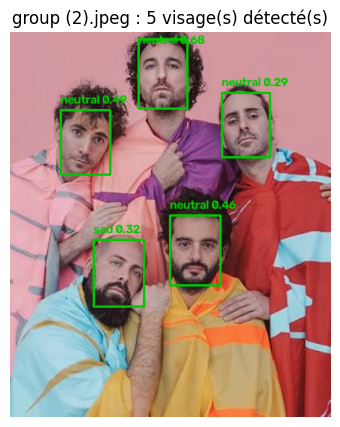

Visage 1 : neutral (0.46) | score de détection 0.87
Visage 2 : neutral (0.68) | score de détection 0.86
Visage 3 : neutral (0.29) | score de détection 0.86
Visage 4 : neutral (0.49) | score de détection 0.85
Visage 5 : sad (0.32) | score de détection 0.80


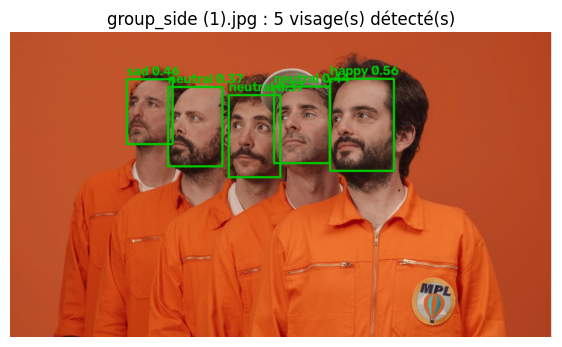

Visage 1 : neutral (0.37) | score de détection 0.85
Visage 2 : happy (0.56) | score de détection 0.84
Visage 3 : neutral (0.44) | score de détection 0.84
Visage 4 : sad (0.46) | score de détection 0.83
Visage 5 : neutral (0.37) | score de détection 0.81


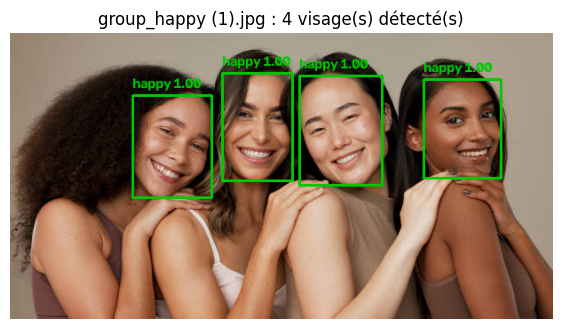

Visage 1 : happy (1.00) | score de détection 0.86
Visage 2 : happy (1.00) | score de détection 0.86
Visage 3 : happy (1.00) | score de détection 0.85
Visage 4 : happy (1.00) | score de détection 0.85


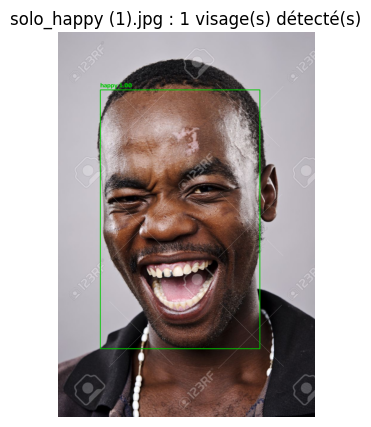

Visage 1 : happy (1.00) | score de détection 0.89


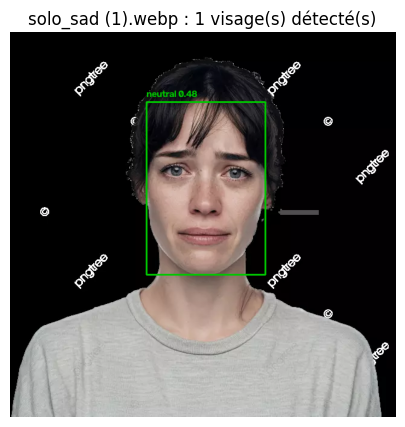

Visage 1 : neutral (0.48) | score de détection 0.88


In [ ]:
from google.colab import files

# Choisir une ou plusieurs photos avec un ou plusieurs visages
up = files.upload()

for nom in up:
    img = cv2.imread(nom)
    resultats = analyser_image(img)
    plt.figure(figsize=(7, 5))
    plt.imshow(cv2.cvtColor(dessiner(img, resultats), cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"{nom} : {len(resultats)} visage(s) détecté(s)")
    plt.show()
    for k, r in enumerate(resultats, 1):
        print(f"Visage {k} : {r['expression']} ({r['proba']:.2f}) | score de détection {r['score_visage']:.2f}")

### Observations

Nous avons testé cinq photos : deux photos d'une seule personne et trois photos de groupe (4 ou 5 personnes). Le détecteur trouve tous les visages sur chacune d'elles, avec des scores de détection entre 0,84 à 0,97.

Sur la photo de groupe où tout le monde sourit, le CNN prédit happy pour les 4 visages avec une probabilité de 1,00. Il fait de même sur la photo seule d'un homme qui rit. Cela correspond au test, car happy est la classe la mieux reconnue.

Sur les deux photos de groupe où les personnes ont un air sérieux, le CNN prédit surtout neutral et sad, avec des probabilités assez basses (de 0,31 à 0,49 pour la plupart, et 0,70 ou 0,79 pour deux visages). Il hésite donc. Sur la photo de la femme triste, il prédit neutral avec 0,48. Les expressions subtiles sont plus difficiles à reconnaître que les grands sourires.

Pour nous, toutes ces prédictions sont correctes ou plausibles. Certaines expressions n'ont pas de vraie étiquette, donc nous ne pouvons pas mesurer une accuracy. Nous jugeons à l'œil, ce qui reste subjectif.

Cette subjectivité aide à comprendre pourquoi notre accuracy sur le test n'est que de 56,6 %. Il est parfois difficile, même pour une personne, de choisir entre deux émotions proches comme sad et neutral. Les labels de FER-2013 sont aussi parfois discutables, comme on l'a vu dans les erreurs de la partie 5. De plus, chaque image n'a qu'une seule étiquette, alors qu'un visage peut montrer plusieurs émotions à la fois, par exemple de la surprise et de la peur. Le modèle doit alors choisir une seule classe. Enfin, notre petit CNN et les images en 48×48 limitent aussi le résultat.

# Partie 9: Extension à la vidéo

Une vidéo est une suite d'images. Pour chaque image, on applique la chaîne de la partie 8 : détection → découpe → CNN → affichage.

Un problème apparaît : sur une vidéo, la prédiction peut changer d'une image à l'autre pour le même visage (effet de clignotement). Pour limiter cela, on lisse les probabilités dans le temps. Un visage est retrouvé d'une image à l'autre grâce à l'IoU de sa boîte avec les boîtes de l'image précédente. Les nouvelles probabilités sont mélangées avec les anciennes (`alpha` = poids des anciennes).

Il vaut mieux tester sur une vidéo courte (10 à 20 secondes).

In [ ]:
import base64
from collections import Counter
from IPython.display import HTML, display
import cv2

# Lissage des probabilités : on cherche, dans l'image précédente, la boîte qui recouvre le plus la nouvelle
def lisser(resultats, precedents, alpha=0.6):
    for r in resultats:
        meilleur, iou_max = None, 0.3
        for q in precedents:
            v = iou(r["box"], q["box"])
            if v > iou_max:
                meilleur, iou_max = q, v
        if meilleur is not None:
            p = alpha * meilleur["probas"] + (1 - alpha) * r["probas"]
            k = int(np.argmax(p))
            r["probas"] = p
            r["expression"] = class_names[k]
            r["proba"] = float(p[k])
    return resultats

def analyser_video(chemin_entree, chemin_sortie="resultat_brut.mp4", pas=2, alpha=0.6):
    cap = cv2.VideoCapture(chemin_entree)
    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    largeur = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    hauteur = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    sortie = cv2.VideoWriter(chemin_sortie, cv2.VideoWriter_fourcc(*"mp4v"), fps, (largeur, hauteur))
    derniers, compteur, n = [], Counter(), 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if n % pas == 0:                       # on analyse une image sur "pas"
            derniers = lisser(analyser_image(frame), derniers, alpha)
            compteur.update(r["expression"] for r in derniers)
        sortie.write(dessiner(frame, derniers))
        n += 1
    cap.release()
    sortie.release()
    return n, compteur

def afficher_video(chemin, largeur=480):
    data = base64.b64encode(open(chemin, "rb").read()).decode()
    display(HTML(f'<video width="{largeur}" controls><source src="data:video/mp4;base64,{data}" type="video/mp4"></video>'))

In [ ]:
from google.colab import files

up = files.upload()                                # tu peux choisir plusieurs vidéos

for i, chemin_video in enumerate(up.keys(), 1):    # une boucle : une vidéo après l'autre
    print(f"--- Vidéo {i} : {chemin_video} ---")
    brut = f"resultat_brut_{i}.mp4"                # un nom différent par vidéo, sinon la suivante écrase la précédente
    final = f"resultat_final_{i}.mp4"

    n_images, compteur = analyser_video(chemin_video, brut)
    print(f"{n_images} images traitées")
    print("Expressions détectées (nombre de visages analysés) :", dict(compteur))

    !ffmpeg -y -loglevel error -i {brut} -vcodec libx264 -pix_fmt yuv420p {final}
    afficher_video(final)
    files.download(final)

Saving 6476835-hd_1080_1920_25fps.mp4 to 6476835-hd_1080_1920_25fps (1).mp4
Saving PXL_20261003_204451110.mp4 to PXL_20261003_204451110 (4).mp4
--- Vidéo 1 : 6476835-hd_1080_1920_25fps (1).mp4 ---
293 images traitées
Expressions détectées (nombre de visages analysés) : {'sad': 269, 'neutral': 63, 'happy': 109}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

--- Vidéo 2 : PXL_20261003_204451110 (4).mp4 ---
159 images traitées
Expressions détectées (nombre de visages analysés) : {'neutral': 2, 'happy': 78}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Observations

Nous avons testé deux vidéos. Dans les deux cas, une image sur deux est analysée.

**Vidéo 1** (293 images, dont 147 analysées) : le détecteur trouve 441 visages, soit 3 par image analysée. Le CNN prédit sad 269 fois (61 %), happy 109 fois (25 %) et neutral 63 fois (14 %). <br>
**Vidéo 2** (159 images, dont 80 analysées) : le détecteur trouve 80 visages, et le CNN prédit happy 78 fois (97,5 %) et neutral 2 fois. Les prédictions sont donc très stables, avec très peu de changements d'une image à l'autre.

Ces chiffres comptent des visages par image, pas des personnes. Quand il y a plusieurs personnes dans l'image, ils mélangent leurs expressions.